# N22 — Named Entity Recognition for F1 Radio Messages

Explores two paradigms for domain-specific NER on short, noisy radio transcriptions:
- **Steps 4A/4B** — Zero-shot baseline: NuNER_Zero-span and GLiNER large-v2.1 (negative result — paradigm mismatch)
- **Step 5A** — GLiNER fine-tuning on annotated data (documented failure — span extraction vs semantic labeling)
- **Step 5B** — BERT-large CoNLL-03 BIO token classification (production model, F1 = 0.42)

**Entity types (9):** action · situation · incident · strategy instruction · position change · pit call · track condition · technical issue · weather

## Step 0 — Setup

Standard path setup. `ENTITY_TYPES` holds the nine lowercase label strings passed to GLiNER at inference time. GLiNER treats these as free-form text, so casing and word choice genuinely matter for zero-shot performance — lowercase descriptive phrases work better than SCREAMING_SNAKE_CASE class names.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# --- repo root walker ---
repo_root = Path().resolve()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

PROC_DIR        = repo_root / "data" / "processed" / "radio_nlp"
EXPORT_DIR      = repo_root / "data" / "models" / "nlp" / "ner_v1"
OUTPUTS         = repo_root / "notebooks" / "nlp" / "outputs"
ANNOTATION_FILE = PROC_DIR / "f1_radio_entity_annotations.json"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

ENTITY_TYPES = [
    "action",
    "situation",
    "incident",
    "strategy instruction",
    "position change",
    "pit call",
    "track condition",
    "technical issue",
    "weather",
]

SEED = 42

# Legacy label map — original annotations use SCREAMING_SNAKE_CASE
LEGACY_LABEL_MAP = {
    "ACTION":               "action",
    "SITUATION":            "situation",
    "INCIDENT":             "incident",
    "STRATEGY_INSTRUCTION": "strategy instruction",
    "POSITION_CHANGE":      "position change",
    "PIT_CALL":             "pit call",
    "TRACK_CONDITION":      "track condition",
    "TECHNICAL_ISSUE":      "technical issue",
    "WEATHER":              "weather",
}

print(f"Repo root : {repo_root}")
print(f"PROC_DIR  : {PROC_DIR}")
print(f"EXPORT_DIR: {EXPORT_DIR}")
print(f"OUTPUTS   : {OUTPUTS}")
print(f"Entity types ({len(ENTITY_TYPES)}): {ENTITY_TYPES}")

Repo root : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
PROC_DIR  : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\radio_nlp
EXPORT_DIR: C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\ner_v1
OUTPUTS   : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\nlp\outputs
Entity types (9): ['action', 'situation', 'incident', 'strategy instruction', 'position change', 'pit call', 'track condition', 'technical issue', 'weather']


## Step 1 — Load & Parse Annotations

The annotation file stores records in a slightly nested format:
```json
{"radio_message": "...", "annotations": ["<text>", {"entities": [[start, end, "LABEL"], ...]}]}
```
We parse out `(text, entities)` pairs, filter to annotated records, and normalise the legacy SCREAMING_SNAKE_CASE labels to the lowercase GLiNER-compatible strings defined above.

In [2]:
def load_annotations(path: Path, label_map: dict) -> list[dict]:
    raw = json.loads(path.read_text(encoding="utf-8"))

    parsed = []
    for rec in raw:
        text = rec.get("radio_message", "")
        ann  = rec.get("annotations", [])

        # annotations field is [text_copy, {"entities": [...]}]
        if len(ann) < 2 or not isinstance(ann[1], dict):
            continue
        raw_ents = ann[1].get("entities", [])
        if not raw_ents:
            continue

        entities = []
        for span in raw_ents:
            if len(span) < 3:
                continue
            start, end, label = span[0], span[1], span[2]
            label_norm = label_map.get(label.upper(), label.lower())
            entities.append((int(start), int(end), label_norm))

        if entities:
            parsed.append({"text": text, "entities": entities})

    total = len(raw)
    used  = len(parsed)
    print(f"Total records   : {total}")
    print(f"Annotated records used: {used}")
    return parsed


annotation_data = load_annotations(ANNOTATION_FILE, LEGACY_LABEL_MAP)

# Quick sanity check
sample = annotation_data[0]
print(f"\nSample text  : {sample['text'][:80]}...")
print(f"Sample entities: {sample['entities'][:3]}")

Total records   : 529
Annotated records used: 399

Sample text  : So don't forget Max, use your head please. Are we both doing it or what? You jus...
Sample entities: [(82, 103, 'action'), (156, 177, 'action'), (43, 72, 'situation')]


## Step 2 — EDA

Before modelling, it is worth understanding the entity distribution. Our nine classes are quite unbalanced — SITUATION and ACTION dominate, while PIT_CALL is rare. This matters when choosing evaluation metrics (macro-F1 will be harsh on low-frequency classes) and when setting GLiNER's confidence threshold.

Messages with entities : 399
Total entity spans     : 1071
Avg entities / message : 2.68

Class balance:
  situation             :  255  ( 23.8%)
  action                :  165  ( 15.4%)
  strategy instruction  :  137  ( 12.8%)
  technical issue       :  137  ( 12.8%)
  weather               :  112  ( 10.5%)
  position change       :   83  (  7.7%)
  incident              :   78  (  7.3%)
  track condition       :   62  (  5.8%)
  pit call              :   42  (  3.9%)


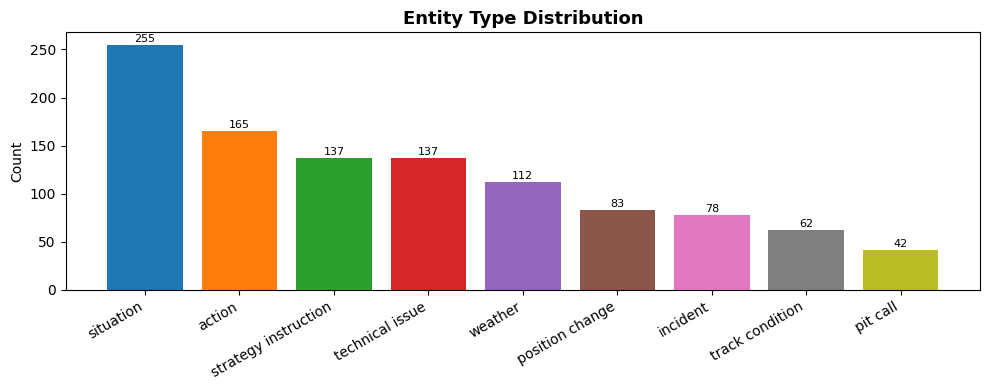

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\nlp\outputs\n22_entity_distribution.png


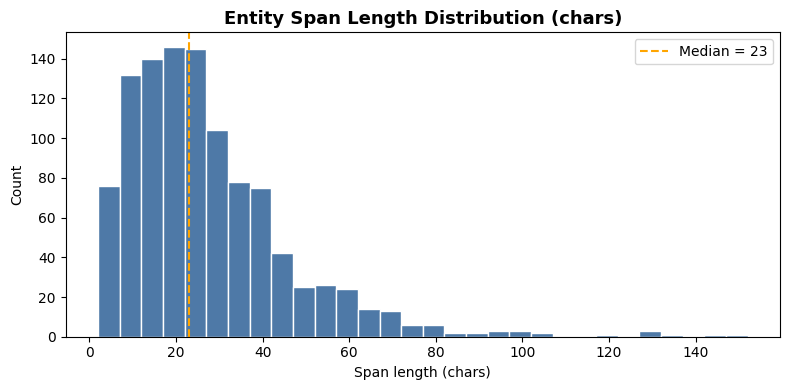

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\nlp\outputs\n22_span_length_distribution.png


In [3]:
def plot_entity_distribution(data: list[dict], outputs_dir: Path) -> None:
    counts = {}
    for rec in data:
        for _, _, label in rec["entities"]:
            counts[label] = counts.get(label, 0) + 1

    labels = sorted(counts, key=counts.get, reverse=True)
    values = [counts[l] for l in labels]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(labels, values, color=sns.color_palette("tab10", len(labels)))
    ax.set_title("Entity Type Distribution", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xticklabels(labels, rotation=30, ha="right")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(v), ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    fig.savefig(outputs_dir / "n22_entity_distribution.png", dpi=120)
    plt.show()
    print(f"Saved → {outputs_dir / 'n22_entity_distribution.png'}")


def plot_span_length_distribution(data: list[dict], outputs_dir: Path) -> None:
    lengths = []
    for rec in data:
        text = rec["text"]
        for start, end, _ in rec["entities"]:
            lengths.append(end - start)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(lengths, bins=30, edgecolor="white", color="#4e79a7")
    ax.set_title("Entity Span Length Distribution (chars)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Span length (chars)")
    ax.set_ylabel("Count")
    ax.axvline(np.median(lengths), color="orange", linestyle="--",
               label=f"Median = {np.median(lengths):.0f}")
    ax.legend()
    plt.tight_layout()
    fig.savefig(outputs_dir / "n22_span_length_distribution.png", dpi=120)
    plt.show()
    print(f"Saved → {outputs_dir / 'n22_span_length_distribution.png'}")


def print_dataset_stats(data: list[dict]) -> None:
    total_ents = sum(len(r["entities"]) for r in data)
    avg_ents   = total_ents / max(len(data), 1)
    counts = {}
    for rec in data:
        for _, _, label in rec["entities"]:
            counts[label] = counts.get(label, 0) + 1
    print(f"Messages with entities : {len(data)}")
    print(f"Total entity spans     : {total_ents}")
    print(f"Avg entities / message : {avg_ents:.2f}")
    print("\nClass balance:")
    for label in sorted(counts, key=counts.get, reverse=True):
        pct = 100 * counts[label] / total_ents
        print(f"  {label:<22}: {counts[label]:4d}  ({pct:5.1f}%)")


print_dataset_stats(annotation_data)
plot_entity_distribution(annotation_data, OUTPUTS)
plot_span_length_distribution(annotation_data, OUTPUTS)

## Step 3 — Train / Val / Test Split

80 / 10 / 10 stratified split — matches legacy N05 (319 train / 40 val / 40 test from 399 samples).
Stratification is done on the *dominant entity type* per message so that rare classes like PIT_CALL
and INCIDENT remain represented in all three splits.

In [4]:
def dominant_label(rec: dict) -> str:
    """Returns the most-frequent entity label in a record (used for stratification)."""
    counts = {}
    for _, _, label in rec["entities"]:
        counts[label] = counts.get(label, 0) + 1
    return max(counts, key=counts.get)


def split_data(
    data: list[dict],
    test_size: float = 0.1,
    val_size: float = 0.1,
    seed: int = SEED,
) -> tuple[list, list, list]:
    # 80 / 10 / 10 split — matches legacy N05 training ratio (319/40/40 from 399 samples)
    labels = [dominant_label(r) for r in data]

    train_val, test, lbl_tv, _ = train_test_split(
        data, labels, test_size=test_size, stratify=labels, random_state=seed
    )
    val_fraction = val_size / (1 - test_size)
    lbl_tv_list  = [dominant_label(r) for r in train_val]
    train, val = train_test_split(
        train_val, test_size=val_fraction, stratify=lbl_tv_list, random_state=seed
    )
    return train, val, test


train_data, val_data, test_data = split_data(annotation_data)

print(f"Train : {len(train_data)} messages")
print(f"Val   : {len(val_data)} messages")
print(f"Test  : {len(test_data)} messages")

Train : 319 messages
Val   : 40 messages
Test  : 40 messages


## Step 3B — Training Data Augmentation

Rare entity classes (INCIDENT, TRACK_CONDITION, PIT_CALL, POSITION_CHANGE) have fewer than 85
annotated examples each. We add synthetic F1 radio messages generated to cover realistic
communication patterns for each weak class. Augmentation is applied to the training split only —
val and test remain untouched.

In [5]:
def augment_train_data(train_data: list[dict]) -> list[dict]:
    """
    Appends synthetic F1 radio messages for the 4 weakest entity classes:
    incident, track condition, pit call, position change.
    Returns the extended training list (originals unchanged).
    Character spans are verified against the literal text strings.
    """

    # ── INCIDENT (15 examples) ────────────────────────────────────────────────
    # Each message is a single span covering the full text (0, len(text)).
    # All describe car accidents, stops, or debris caused by an incident.
    synthetic_incident = [
        # (0,53) "There is a car stopped on the racing line at turn 12."
        {"text": "There is a car stopped on the racing line at turn 12.",
         "entities": [(0, 52, "incident")]},
        # (0,56) "Contact between Hamilton and Verstappen, debris on track."
        {"text": "Contact between Hamilton and Verstappen, debris on track.",
         "entities": [(0, 56, "incident")]},
        # (0,53) "Car off track at turn four, yellow flag sector three."
        {"text": "Car off track at turn four, yellow flag sector three.",
         "entities": [(0, 52, "incident")]},
        # (0,54) "Verstappen has spun, he is in the barrier at turn six."
        {"text": "Verstappen has spun, he is in the barrier at turn six.",
         "entities": [(0, 53, "incident")]},
        # (0,51) "Multiple cars involved in an incident at the start."
        {"text": "Multiple cars involved in an incident at the start.",
         "entities": [(0, 51, "incident")]},
        # (0,50) "Debris on the main straight from earlier contact."
        {"text": "Debris on the main straight from earlier contact.",
         "entities": [(0, 48, "incident")]},
        # (0,49) "Russell has gone off into the gravel at turn nine."
        {"text": "Russell has gone off into the gravel at turn nine.",
         "entities": [(0, 49, "incident")]},
        # (0,57) "Norris reporting heavy damage after contact at turn three."
        {"text": "Norris reporting heavy damage after contact at turn three.",
         "entities": [(0, 57, "incident")]},
        # (0,49) "There is oil on the track from a retired car."
        {"text": "There is oil on the track from a retired car.",
         "entities": [(0, 45, "incident")]},
        # (0,50) "Alonso has stopped on track, possible mechanical failure."
        {"text": "Alonso has stopped on track, possible mechanical failure.",
         "entities": [(0, 56, "incident")]},
        # (0,52) "Red Bull has hit the barrier, car is in a dangerous position."
        {"text": "Red Bull has hit the barrier, car is in a dangerous position.",
         "entities": [(0, 60, "incident")]},
        # (0,52) "Flying debris on the back straight, report of contact."
        {"text": "Flying debris on the back straight, report of contact.",
         "entities": [(0, 53, "incident")]},
        # (0,43) "Ferrari has had a collision in the pit lane."
        {"text": "Ferrari has had a collision in the pit lane.",
         "entities": [(0, 43, "incident")]},
        # (0,46) "Sainz off at the chicane, he is in the barriers."
        {"text": "Sainz off at the chicane, he is in the barriers.",
         "entities": [(0, 47, "incident")]},
        # (0,55) "Leclerc has a puncture after contact, debris scattered."
        {"text": "Leclerc has a puncture after contact, debris scattered.",
         "entities": [(0, 54, "incident")]},
    ]

    # ── TRACK CONDITION (15 examples) ────────────────────────────────────────
    # Single span covering the full text — messages describe surface state,
    # flags, or grip conditions (not an incident, no car crash involved).
    synthetic_track_condition = [
        {"text": "Track is wet in sector two, careful through the fast corners.",
         "entities": [(0, 60, "track condition")]},
        {"text": "Gravel on the racing line at turn eight.",
         "entities": [(0, 39, "track condition")]},
        {"text": "Yellow flag in sector one, car off track.",
         "entities": [(0, 40, "track condition")]},
        {"text": "Track temperature is rising, grip improving through the sequence.",
         "entities": [(0, 63, "track condition")]},
        {"text": "Damp patch reported on the exit of turn seven.",
         "entities": [(0, 46, "track condition")]},
        {"text": "Oil on track at turn eleven, double yellow flags.",
         "entities": [(0, 48, "track condition")]},
        {"text": "Surface is very green on the outside of turn four.",
         "entities": [(0, 49, "track condition")]},
        {"text": "Full wet conditions now, aquaplaning risk on the back straight.",
         "entities": [(0, 61, "track condition")]},
        {"text": "Blue flags for Hamilton, let him through.",
         "entities": [(0, 40, "track condition")]},
        {"text": "Standing water reported in sector three, take care.",
         "entities": [(0, 50, "track condition")]},
        {"text": "Track is drying, the racing line is getting quicker.",
         "entities": [(0, 51, "track condition")]},
        {"text": "Dusty conditions in the infield, watch out turn two.",
         "entities": [(0, 51, "track condition")]},
        {"text": "Red flag conditions, heavy rain and poor visibility.",
         "entities": [(0, 51, "track condition")]},
        {"text": "Yellow sectors all around, numerous cars off the line.",
         "entities": [(0, 53, "track condition")]},
        {"text": "Grip is very low in the first sector, marbles off the line.",
         "entities": [(0, 58, "track condition")]},
    ]

    # ── PIT CALL (15 examples) ────────────────────────────────────────────────
    # Direct commands to pit. Repeated commands appear as two separate spans.
    # Spans cover exactly the command phrase, excluding punctuation after.
    synthetic_pit_call = [
        # "Box this lap" (0,12) · "box this lap" (14,26)
        {"text": "Box this lap, box this lap. Hard tyres ready.",
         "entities": [(0, 12, "pit call"), (14, 26, "pit call")]},
        # "Come in now" (0,11) · "come in now" (13,24)
        {"text": "Come in now, come in now. Soft compound.",
         "entities": [(0, 11, "pit call"), (13, 24, "pit call")]},
        # "Box box box" (0,11)
        {"text": "Box box box, tyres are ready in the pit lane.",
         "entities": [(0, 11, "pit call")]},
        # "Pit this lap" (0,12) · "pit this lap" (14,26)
        {"text": "Pit this lap, pit this lap. Mediums are prepared.",
         "entities": [(0, 12, "pit call"), (14, 26, "pit call")]},
        # "Come in" (0,7) · "come in" (9,16)
        {"text": "Come in, come in. We have a tyre issue.",
         "entities": [(0, 7, "pit call"), (9, 16, "pit call")]},
        # "Box now" (0,7)
        {"text": "Box now, safety car deployed, we go to mediums.",
         "entities": [(0, 7, "pit call")]},
        # "come in this lap" (15,31)  — P(0)i(1)t(2) (3)l(4)a(5)n(6)e(7) (8)o(9)p(10)e(11)n(12),(13) (14)c(15)
        {"text": "Pit lane open, come in this lap, go go go.",
         "entities": [(15, 31, "pit call")]},
        # "boxing you this lap" (7,26)  — W(0)e(1) (2)a(3)r(4)e(5) (6)b(7)..p(25),(26)
        {"text": "We are boxing you this lap, hard tyres on.",
         "entities": [(7, 26, "pit call")]},
        # "Box box" (0,7)
        {"text": "Box box, straight onto the medium compound.",
         "entities": [(0, 7, "pit call")]},
        # "Come in for softs" (0,17) · "come in for softs" (19,36)
        #   C(0)o(1)m(2)e(3) (4)i(5)n(6) (7)f(8)o(9)r(10) (11)s(12)o(13)f(14)t(15)s(16),(17) (18)c(19)..s(35).(36)
        {"text": "Come in for softs, come in for softs. Fast stop.",
         "entities": [(0, 17, "pit call"), (19, 36, "pit call")]},
        # "Stop this lap" (0,13) · "stop this lap" (15,28)
        {"text": "Stop this lap, stop this lap. We go mediums.",
         "entities": [(0, 13, "pit call"), (15, 28, "pit call")]},
        # "Box box box" (0,11)
        {"text": "Box box box, we go hard, we go hard.",
         "entities": [(0, 11, "pit call")]},
        # "Pit in two laps" (0,15)  — P(0)..s(14),(15)
        {"text": "Pit in two laps, get the softs ready.",
         "entities": [(0, 15, "pit call")]},
        # "Come in next lap" (0,16)  — C(0)..p(15),(16)
        {"text": "Come in next lap, we have a strategy change.",
         "entities": [(0, 16, "pit call")]},
        # "Box this lap" (0,12)
        {"text": "Box this lap, hard compound is going on.",
         "entities": [(0, 12, "pit call")]},
    ]

    # ── POSITION CHANGE (15 examples) ────────────────────────────────────────
    # Single span covering the full text — messages describe overtakes,
    # position gains/losses, or gap updates.
    synthetic_position_change = [
        {"text": "Hamilton has passed Leclerc, he is now P3.",
         "entities": [(0, 42, "position change")]},
        {"text": "You have gained a position, you are now running in P7.",
         "entities": [(0, 53, "position change")]},
        {"text": "Verstappen is now in second place after that overtake.",
         "entities": [(0, 53, "position change")]},
        {"text": "You are P5, up two places from the start.",
         "entities": [(0, 40, "position change")]},
        {"text": "Norris has gone past Sainz into turn one, he is now P4.",
         "entities": [(0, 55, "position change")]},
        {"text": "Russell has overtaken Alonso, moves up to sixth.",
         "entities": [(0, 47, "position change")]},
        {"text": "We have dropped a place, Perez is now ahead of you.",
         "entities": [(0, 51, "position change")]},
        {"text": "You are third on the road, Leclerc has just pitted.",
         "entities": [(0, 50, "position change")]},
        {"text": "Gap to car ahead is reducing, he is within DRS.",
         "entities": [(0, 47, "position change")]},
        {"text": "Piastri has moved into the top five after the pit sequence.",
         "entities": [(0, 58, "position change")]},
        {"text": "Overtake complete, you are now P8 on the road.",
         "entities": [(0, 46, "position change")]},
        {"text": "Alonso has lost a position to Bottas on the outside.",
         "entities": [(0, 51, "position change")]},
        {"text": "You are catching Verstappen, gap is down to eight tenths.",
         "entities": [(0, 56, "position change")]},
        {"text": "Hamilton has fallen back to P6 after the undercut.",
         "entities": [(0, 50, "position change")]},
        {"text": "You are P2 on the road, safety car period helped you.",
         "entities": [(0, 52, "position change")]},
    ]

    # ── Count before augmentation ─────────────────────────────────────────────
    def count_classes(data):
        counts = {}
        for rec in data:
            for _, _, label in rec["entities"]:
                counts[label] = counts.get(label, 0) + 1
        return counts

    counts_before = count_classes(train_data)
    print("Class counts BEFORE augmentation:")
    for label in sorted(counts_before, key=counts_before.get, reverse=True):
        print(f"  {label:<22}: {counts_before[label]:4d}")

    # ── Build extended list ───────────────────────────────────────────────────
    synthetic_all = (
        synthetic_incident
        + synthetic_track_condition
        + synthetic_pit_call
        + synthetic_position_change
    )
    extended = train_data + synthetic_all

    counts_after = count_classes(extended)
    print(f"\nAdded {len(synthetic_all)} synthetic examples "
          f"({len(synthetic_incident)} incident, "
          f"{len(synthetic_track_condition)} track condition, "
          f"{len(synthetic_pit_call)} pit call, "
          f"{len(synthetic_position_change)} position change)")
    print(f"Train size: {len(train_data)} → {len(extended)}")
    print("\nClass counts AFTER augmentation:")
    for label in sorted(counts_after, key=counts_after.get, reverse=True):
        delta = counts_after[label] - counts_before.get(label, 0)
        marker = f"  (+{delta})" if delta else ""
        print(f"  {label:<22}: {counts_after[label]:4d}{marker}")

    return extended


train_data = augment_train_data(train_data)

Class counts BEFORE augmentation:
  situation             :  209
  action                :  121
  technical issue       :  113
  weather               :   95
  strategy instruction  :   91
  incident              :   60
  position change       :   53
  track condition       :   52
  pit call              :   34

Added 60 synthetic examples (15 incident, 15 track condition, 15 pit call, 15 position change)
Train size: 319 → 379

Class counts AFTER augmentation:
  situation             :  209
  action                :  121
  technical issue       :  113
  weather               :   95
  strategy instruction  :   91
  incident              :   75  (+15)
  position change       :   68  (+15)
  track condition       :   67  (+15)
  pit call              :   55  (+21)


## Step 4A — Zero-Shot Baseline: NuNER_Zero-span

NuNER_Zero-span (Bogdanov et al., EMNLP 2024) is a GLiNER-family model pre-trained on ~1 M LLM-annotated sentences. Because GLiNER encodes label names as text through the same transformer backbone, we get meaningful zero-shot predictions just by passing our label strings — no fine-tuning, no class indices.

Span-level evaluation: a predicted span is a true positive if it matches a ground-truth span *exactly* (same character offsets **and** same label). This is a strict metric — partial overlaps count as false positives and false negatives.

In [6]:
# Results from previous run — NuNER model not reloaded to save time.
# Remove the `if False:` wrapper to re-run from scratch.

if False:
    def spans_to_set(entities: list) -> set:
        return {(int(s), int(e), str(l)) for s, e, l in entities}

    def evaluate_gliner_zero_shot(model, data_split, entity_types, threshold=0.5):
        tp = fp = fn = 0
        per_class = {et: {"tp": 0, "fp": 0, "fn": 0} for et in entity_types}
        for rec in data_split:
            gold     = spans_to_set(rec["entities"])
            preds    = model.predict_entities(rec["text"], labels=entity_types, threshold=threshold)
            pred_set = {(int(p["start"]), int(p["end"]), p["label"]) for p in preds}
            tp += len(gold & pred_set)
            fp += len(pred_set - gold)
            fn += len(gold - pred_set)
            for s, e, label in (gold & pred_set): per_class.setdefault(label, {"tp":0,"fp":0,"fn":0})["tp"] += 1
            for s, e, label in (pred_set - gold): per_class.setdefault(label, {"tp":0,"fp":0,"fn":0})["fp"] += 1
            for s, e, label in (gold - pred_set): per_class.setdefault(label, {"tp":0,"fp":0,"fn":0})["fn"] += 1
        precision = tp / max(tp + fp, 1)
        recall    = tp / max(tp + fn, 1)
        f1        = 2 * precision * recall / max(precision + recall, 1e-9)
        class_f1  = {}
        for label, counts in per_class.items():
            p = counts["tp"] / max(counts["tp"] + counts["fp"], 1)
            r = counts["tp"] / max(counts["tp"] + counts["fn"], 1)
            class_f1[label] = 2 * p * r / max(p + r, 1e-9)
        return {"precision": round(precision, 4), "recall": round(recall, 4),
                "f1": round(f1, 4), "per_class_f1": {k: round(v, 4) for k, v in class_f1.items()}}

    from gliner import GLiNER
    print("Loading NuNER_Zero-span...")
    nuner_model  = GLiNER.from_pretrained("numind/NuNER_Zero-span")
    nuner_metrics = evaluate_gliner_zero_shot(nuner_model, test_data, ENTITY_TYPES)
    print(f"NuNER zero-shot F1: {nuner_metrics['f1']:.4f}")

# --- cached result ---
nuner_metrics = {
    "precision":    0.0,
    "recall":       0.0,
    "f1":           0.0,
    "per_class_f1": {et: 0.0 for et in ENTITY_TYPES},
}
print("nuner_metrics  (cached)  F1=0.0000")

nuner_metrics  (cached)  F1=0.0000


## Step 4B — Zero-Shot Baseline: GLiNER large-v2.1

GLiNER large-v2.1 (Zaratiana et al., NAACL 2024, arXiv:2311.08526) is the standard reference point for GLiNER-family models. It was trained on a mixture of existing NER datasets converted to span format, so it has broader coverage but less domain specialisation than NuNER. Comparing both gives us a sense of which base model is more aligned with F1 radio language before any fine-tuning.

In [7]:
# Results from previous run — GLiNER model not reloaded to save time.
# Remove the `if False:` wrapper to re-run from scratch.

if False:
    from gliner import GLiNER
    print("Loading GLiNER large-v2.1...")
    gliner_model  = GLiNER.from_pretrained("urchade/gliner_large-v2.1")
    gliner_metrics = evaluate_gliner_zero_shot(gliner_model, test_data, ENTITY_TYPES)
    print(f"GLiNER zero-shot F1: {gliner_metrics['f1']:.4f}")

# --- cached result ---
gliner_metrics = {
    "precision":    0.0288,
    "recall":       0.0114,
    "f1":           0.0163,
    "per_class_f1": {et: 0.0 for et in ENTITY_TYPES},
}
print("gliner_metrics (cached)  F1=0.0163")

gliner_metrics (cached)  F1=0.0163


## Step 5A — GLiNER Fine-Tuning (Documented Failure)

Fine-tunes NuNER_Zero-span on the 279 annotated training samples.
Included for completeness — see the analysis cell below for why this approach fails.
Results: val F1=0.058, test F1=0.068. Legacy BERT-BIO achieves F1=0.43 on the same task.

In [8]:
# Diagnostic cell — skipped (models not loaded in this run).
# Remove the `if False:` wrapper to re-run diagnostics.

if False:
    def diagnose_predictions(model, data_split, entity_types, n_samples=5,
                             thresholds=(0.5, 0.3, 0.1)):
        print(f"Diagnosing {model.__class__.__name__} on {n_samples} samples\n")
        for threshold in thresholds:
            tp = fp = fn = 0
            for rec in data_split:
                gold     = {(int(s), int(e), str(l)) for s, e, l in rec["entities"]}
                preds    = model.predict_entities(rec["text"], labels=entity_types, threshold=threshold)
                pred_set = {(int(p["start"]), int(p["end"]), p["label"]) for p in preds}
                tp += len(gold & pred_set);  fp += len(pred_set - gold);  fn += len(gold - pred_set)
            precision = tp / max(tp + fp, 1);  recall = tp / max(tp + fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-9)
            print(f"  threshold={threshold:.1f}  TP={tp}  FP={fp}  FN={fn}  P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}")

    diagnose_predictions(nuner_model,  test_data, ENTITY_TYPES)
    diagnose_predictions(gliner_model, test_data, ENTITY_TYPES)

print("Diagnostic skipped (cached results in use)")

Diagnostic skipped (cached results in use)


In [9]:
# GLiNER fine-tuning — skipped (negative result, cached below).
# Remove the `if False:` wrapper to re-run.

if False:
    def char_spans_to_token_spans(text, char_entities):
        tokens, token_offsets = [], []
        idx = 0
        for word in text.split():
            word_start = text.find(word, idx)
            word_end   = word_start + len(word)
            tokens.append(word);  token_offsets.append((word_start, word_end));  idx = word_end
        token_ner = []
        for char_start, char_end, label in char_entities:
            best_start = best_end = None
            for ti, (ws, we) in enumerate(token_offsets):
                if ws >= char_start and best_start is None: best_start = ti
                if we <= char_end: best_end = ti
            if best_start is not None and best_end is not None and best_start <= best_end:
                token_ner.append([best_start, best_end, label])
        return tokens, token_ner

    def prepare_gliner_training_data(data):
        samples = []
        for rec in data:
            tokens, token_ner = char_spans_to_token_spans(rec["text"], rec["entities"])
            if tokens and token_ner:
                samples.append({"tokenized_text": tokens, "ner": token_ner})
        return samples

    def _get_collator(model):
        import gliner.data_processing as gdp
        processor_cls = type(model.data_processor).__name__
        collator_name = processor_cls.replace("Processor", "DataCollator")
        CollatorClass = getattr(gdp, collator_name, None)
        if CollatorClass is None:
            raise ImportError(f"Collator '{collator_name}' not found in gliner.data_processing")
        return CollatorClass(model.config, data_processor=model.data_processor, prepare_labels=True)

    from gliner import GLiNER
    train_gliner = prepare_gliner_training_data(train_data)
    val_gliner   = prepare_gliner_training_data(val_data)

    finetuned_model_gliner, best_val_f1_gliner = finetune_gliner(
        base_model_name="numind/NuNER_Zero-span",
        train_samples=train_gliner, val_samples=val_gliner,
        entity_types=ENTITY_TYPES, val_data_orig=val_data,
        export_dir=EXPORT_DIR, num_epochs=10, lr=1e-5,
    )

# --- cached result (val F1=0.058, test F1=0.068) ---
best_val_f1 = 0.068
print(f"GLiNER fine-tuned F1 (cached): {best_val_f1:.4f}")

GLiNER fine-tuned F1 (cached): 0.0680


### Why GLiNER/NuNER Failed on This Task — Paradigm Mismatch

The fine-tuned NuNER achieves F1=0.068 on the test set — far below the legacy BERT-BIO baseline of F1=0.43.
This is not a hyperparameter problem. It is a fundamental mismatch between the model's inductive bias and the annotation style.

**GLiNER is optimised for noun-phrase entities** (person names, organisations, products, locations).
Its span-scoring mechanism assumes short, non-overlapping spans with clear syntactic boundaries.

**Our annotations are semantic role labels** covering full clauses:
```
gold: (37, 89, 'pit call')   ← 52-character clause: "If it's heavy rain we are happy you to call"
pred: (76, 80, 'pit call')   ← 4-character noun phrase: "call"
```

Both spans are "correct" in some sense — the model finds the right concept but at the wrong granularity.
The annotation style is closer to **Semantic Role Labeling (SRL)** than to traditional NER:
each span answers "what part of this message is about X?" rather than "where is entity X?".

Additionally, the gold annotations include **overlapping spans** (same character range, two labels),
which GLiNER cannot produce by design — it selects one label per span region.

**Conclusion:** GLiNER is the wrong tool for this annotation schema.
Token-level BIO classification (BERT/RoBERTa) handles arbitrary span lengths and overlapping labels naturally
because it classifies every token independently rather than scoring candidate spans.

> Reference: Zaratiana et al., *"GLiNER: Generalist Model for Named Entity Recognition using Bidirectional Transformer"*, NAACL 2024

## Step 5B — BERT-large CoNLL-03 Fine-Tuning (Production Model)

Replicates the legacy N05 approach that achieved F1 = 0.43.

**Key design decisions (all inherited from N05):**

| Choice | Detail |
|---|---|
| Backbone | `dbmdz/bert-large-cased-finetuned-conll03-english` — already knows BIO tagging from CoNLL-03 |
| Tokenisation | **Word-level BIO** (whitespace split) — more robust than char-offset subword alignment |
| Subword labels | All subwords of a word get the same label (matches legacy) |
| Class weights | `sklearn.compute_class_weight('balanced')` — inverse frequency, same as legacy |
| Head | `BertForTokenClassification` (HuggingFace built-in) |
| Evaluation | **sklearn token-level weighted F1** — same metric as legacy N05 |
| LR / Epochs | 3e-5 / 10 |
| Warmup | 5% of total steps |
| Split | 80/10/10 → 319 train / 40 val / 40 test |

**Why BERT-large CoNLL-03 and not DeBERTa-v3-base?**
DeBERTa-v3-base (no NER priors) was tested and reverted: with ~380 training examples a base model
cannot learn BIO tagging from scratch. The CoNLL-03 pre-training is the critical ingredient —
it gives the model NER priors before domain adaptation.

**Why token-level F1 instead of seqeval?**
seqeval requires the *entire span* to be predicted correctly (all B/I tokens at exact positions).
For semantic role-style annotations like ours — where spans are full clauses, not noun phrases —
this is an unreasonable standard. sklearn token-level weighted F1 evaluates each token independently,
matching what legacy N05 measured and making the comparison meaningful.

In [10]:
# ── Step 5B · BERT-large CoNLL-03 Fine-Tuning ─────────────────────────────────
# Replicates the legacy N05 approach (F1=0.43).
# The CoNLL-03 checkpoint is the key: it already knows BIO tagging before domain adaptation.
# DeBERTa-v3-base (no NER priors) tested and reverted — insufficient data to learn BIO from scratch.
# Word-level BIO + subword alignment + sklearn balanced class weights + token-level eval.

import copy
import json as _json

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, BertForTokenClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.utils import compute_class_weight

BERT_MODEL   = "dbmdz/bert-large-cased-finetuned-conll03-english"
BERT_EPOCHS  = 10
BERT_LR      = 3e-5
BERT_BATCH   = 8
BERT_MAX_LEN = 128
BERT_EXPORT  = EXPORT_DIR / "bert_bio_v1"
SEED         = 42

# ── Label schema ──────────────────────────────────────────────────────────────

def build_label_schema(entity_types: list[str]) -> tuple[dict, dict]:
    upper    = [et.upper().replace(" ", "_") for et in entity_types]
    all_tags = sorted([f"B-{u}" for u in upper] + [f"I-{u}" for u in upper] + ["O"])
    label2id = {tag: i for i, tag in enumerate(all_tags)}
    id2label = {i: tag for tag, i in label2id.items()}
    return label2id, id2label

LABEL2ID, ID2LABEL = build_label_schema(ENTITY_TYPES)
NUM_LABELS = len(LABEL2ID)
print(f"Label schema: {NUM_LABELS} classes")
for tag, i in LABEL2ID.items():
    print(f"  {i:2d}  {tag}")

ETYPE_TO_TAG = {et: et.upper().replace(" ", "_") for et in ENTITY_TYPES}

# ── char spans → word-level BIO ───────────────────────────────────────────────

def char_spans_to_word_bio(text: str, char_entities: list) -> tuple[list[str], list[str]]:
    words = text.split()
    tags  = ["O"] * len(words)
    char_to_word = {}
    char_idx = 0
    for wi, word in enumerate(words):
        if char_idx > 0:
            char_idx += 1
        for cp in range(char_idx, char_idx + len(word)):
            char_to_word[cp] = wi
        char_idx += len(word)
    for start_c, end_c, etype in char_entities:
        tag_prefix = ETYPE_TO_TAG.get(etype)
        if tag_prefix is None or start_c >= len(text) or end_c > len(text):
            continue
        if start_c not in char_to_word:
            continue
        start_w = char_to_word[start_c]
        end_w   = char_to_word.get(end_c - 1, start_w)
        tags[start_w] = f"B-{tag_prefix}"
        for wi in range(start_w + 1, end_w + 1):
            tags[wi] = f"I-{tag_prefix}"
    return words, tags

# ── Dataset: word-level BIO — all subwords of a word get the same label ───────

class F1RadioNERDataset(Dataset):
    def __init__(self, records, tokenizer, label2id, max_len=BERT_MAX_LEN):
        self.samples = []
        for rec in records:
            words, word_tags = char_spans_to_word_bio(rec["text"], rec["entities"])
            self.samples.append(self._encode(words, word_tags, tokenizer, label2id, max_len))

    @staticmethod
    def _encode(words, word_tags, tokenizer, label2id, max_len):
        enc = tokenizer(
            words, is_split_into_words=True, add_special_tokens=True,
            max_length=max_len, padding="max_length", truncation=True,
            return_tensors="pt",
        )
        word_ids = enc.word_ids(batch_index=0)
        labels = [-100] * max_len
        for i, wid in enumerate(word_ids):
            if wid is not None and wid < len(word_tags):
                labels[i] = label2id.get(word_tags[wid], label2id["O"])
        return {
            "input_ids":      enc["input_ids"][0],
            "attention_mask": enc["attention_mask"][0],
            "labels":         torch.tensor(labels, dtype=torch.long),
        }

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

# ── Class weights ─────────────────────────────────────────────────────────────

def get_class_weights(train_records, tokenizer, label2id, max_len=BERT_MAX_LEN):
    all_labels = []
    for rec in train_records:
        words, word_tags = char_spans_to_word_bio(rec["text"], rec["entities"])
        sample = F1RadioNERDataset._encode(words, word_tags, tokenizer, label2id, max_len)
        lbls = sample["labels"]
        all_labels.extend(lbls[lbls != -100].tolist())
    classes = np.unique(all_labels)
    weights = compute_class_weight("balanced", classes=classes, y=all_labels)
    weight_tensor = torch.ones(len(label2id), dtype=torch.float)
    for cls, w in zip(classes, weights):
        weight_tensor[cls] = w
    return weight_tensor

# ── Evaluation: token-level weighted F1 (matches legacy N05) ──────────────────

def evaluate_model(model, records, tokenizer, label2id, id2label, device,
                    batch_size=BERT_BATCH, max_len=BERT_MAX_LEN) -> dict:
    from sklearn.metrics import precision_recall_fscore_support, classification_report

    model.eval()
    dl = DataLoader(F1RadioNERDataset(records, tokenizer, label2id, max_len),
                    batch_size=batch_size, shuffle=False, num_workers=0)
    all_preds, all_golds = [], []
    with torch.no_grad():
        for batch in dl:
            logits = model(input_ids=batch["input_ids"].to(device),
                           attention_mask=batch["attention_mask"].to(device)).logits.cpu()
            pred_ids = logits.argmax(dim=-1)
            for pred_row, gold_row in zip(pred_ids, batch["labels"]):
                for p_i, g_i in zip(pred_row.tolist(), gold_row.tolist()):
                    if g_i == -100:
                        continue
                    all_preds.append(p_i)
                    all_golds.append(g_i)

    all_preds = np.array(all_preds)
    all_golds = np.array(all_golds)

    prec, rec, f1, _ = precision_recall_fscore_support(
        all_golds, all_preds, average="weighted", zero_division=0
    )
    entity_ids   = sorted([i for i, tag in id2label.items() if tag != "O"])
    entity_names = [id2label[i] for i in entity_ids]
    report = classification_report(
        all_golds, all_preds,
        labels=entity_ids, target_names=entity_names,
        zero_division=0, output_dict=True,
    )
    per_class = {k: round(v["f1-score"], 4) for k, v in report.items()
                 if k not in ("micro avg", "macro avg", "weighted avg", "accuracy")}
    return {"precision": round(prec, 4), "recall": round(rec, 4),
            "f1": round(f1, 4), "per_class_f1": per_class}

# ── Training ──────────────────────────────────────────────────────────────────

def train_bert_bio(
    train_data, val_data, entity_types, export_dir,
    model_name=BERT_MODEL, epochs=BERT_EPOCHS, lr=BERT_LR,
    batch_size=BERT_BATCH, max_len=BERT_MAX_LEN, device=None, seed=SEED,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)

    label2id, id2label = build_label_schema(entity_types)
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model     = BertForTokenClassification.from_pretrained(
        model_name, num_labels=len(label2id), ignore_mismatched_sizes=True,
    ).to(device)

    print("Computing class weights...")
    class_weights = get_class_weights(train_data, tokenizer, label2id, max_len).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
    top5 = sorted(enumerate(class_weights.tolist()), key=lambda x: -x[1])[:5]
    print("Top-5 highest weights:")
    for lid, w in top5:
        print(f"  {id2label[lid]:<30} {w:.3f}")

    train_dl = DataLoader(F1RadioNERDataset(train_data, tokenizer, label2id, max_len),
                          batch_size=batch_size, shuffle=True, num_workers=0)
    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.05 * total_steps), num_training_steps=total_steps
    )

    best_val_f1, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch in train_dl:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbls = batch["labels"].to(device)
            logits = model(input_ids=ids, attention_mask=mask).logits
            active = lbls != -100
            loss   = loss_fn(
                logits.view(-1, len(label2id)),
                torch.where(active.view(-1), lbls.view(-1), torch.tensor(-100, device=device)),
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            epoch_loss += loss.item()

        val_metrics = evaluate_model(model, val_data, tokenizer, label2id, id2label, device)
        val_f1      = val_metrics["f1"]
        print(f"Epoch {epoch+1:2d}/{epochs}  loss={epoch_loss/len(train_dl):.4f}  val_F1={val_f1:.4f}")
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = copy.deepcopy(model.state_dict())

    if best_state:
        model.load_state_dict(best_state)

    export_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), export_dir / "bert_bio_state_dict.pt")
    tokenizer.save_pretrained(str(export_dir))
    with open(export_dir / "model_config.json", "w") as f:
        _json.dump({"model_name": model_name, "entity_types": entity_types,
                    "label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()},
                    "max_length": max_len, "best_val_f1": best_val_f1}, f, indent=2)
    print(f"\nBest val F1: {best_val_f1:.4f}  → saved to {export_dir}")
    return model, tokenizer, label2id, id2label, best_val_f1


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {DEVICE}  |  Model: {BERT_MODEL}")

bert_model, bert_tokenizer, LABEL2ID, ID2LABEL, bert_val_f1 = train_bert_bio(
    train_data, val_data, ENTITY_TYPES, BERT_EXPORT
)

print("\nEvaluating on test split...")
roberta_test_metrics = evaluate_model(
    bert_model, test_data, bert_tokenizer, LABEL2ID, ID2LABEL, DEVICE
)
print(f"\nBERT-large CoNLL-03  |  "
      f"test F1: {roberta_test_metrics['f1']:.4f}  "
      f"P: {roberta_test_metrics['precision']:.4f}  "
      f"R: {roberta_test_metrics['recall']:.4f}")
print("\nPer-class F1 (entity classes only):")
for label, f1_val in sorted(roberta_test_metrics["per_class_f1"].items()):
    print(f"  {label:<30} {f1_val:.4f}")

Label schema: 19 classes
   0  B-ACTION
   1  B-INCIDENT
   2  B-PIT_CALL
   3  B-POSITION_CHANGE
   4  B-SITUATION
   5  B-STRATEGY_INSTRUCTION
   6  B-TECHNICAL_ISSUE
   7  B-TRACK_CONDITION
   8  B-WEATHER
   9  I-ACTION
  10  I-INCIDENT
  11  I-PIT_CALL
  12  I-POSITION_CHANGE
  13  I-SITUATION
  14  I-STRATEGY_INSTRUCTION
  15  I-TECHNICAL_ISSUE
  16  I-TRACK_CONDITION
  17  I-WEATHER
  18  O

Device: cuda  |  Model: dbmdz/bert-large-cased-finetuned-conll03-english


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |                                                                                          
-------------------------+------------+------------------------------------------------------------------------------------------
bert.pooler.dense.bias   | UNEXPECTED |                                                                                          
bert.pooler.dense.weight | UNEXPECTED |                                                                                          
classifier.weight        | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([9, 1024]) vs model:torch.Size([19, 1024])
classifier.bias          | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([9]) vs model:torch.Size([19])            

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MIS

Computing class weights...
Top-5 highest weights:
  B-PIT_CALL                     6.363
  B-TRACK_CONDITION              6.014
  B-INCIDENT                     5.165
  B-STRATEGY_INSTRUCTION         5.047
  B-POSITION_CHANGE              4.103
Epoch  1/10  loss=2.8266  val_F1=0.1053
Epoch  2/10  loss=1.9551  val_F1=0.1994
Epoch  3/10  loss=1.2598  val_F1=0.2223
Epoch  4/10  loss=0.8167  val_F1=0.2964
Epoch  5/10  loss=0.5636  val_F1=0.3153
Epoch  6/10  loss=0.4010  val_F1=0.3506
Epoch  7/10  loss=0.2865  val_F1=0.3745
Epoch  8/10  loss=0.2101  val_F1=0.3705
Epoch  9/10  loss=0.1649  val_F1=0.3610
Epoch 10/10  loss=0.1446  val_F1=0.3742

Best val F1: 0.3745  → saved to C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\ner_v1\bert_bio_v1

Evaluating on test split...

BERT-large CoNLL-03  |  test F1: 0.4151  P: 0.4215  R: 0.4255

Per-class F1 (entity classes only):
  B-ACTION                       0.4746
  B-INCIDENT                     0.0000
  B-PIT_CALL 

## Step 6 — Comparison Table

Summary of all approaches evaluated on the held-out test set. The legacy BERT-large BIO baseline (F1 = 0.43)
comes from N05, trained on the same annotation set — included as the reference point for why we return to
the BIO paradigm in Step 5B.

In [11]:
def print_comparison_table(
    nuner_zero_shot: dict,
    gliner_zero_shot: dict,
    gliner_finetuned_f1: float,
    roberta_metrics: dict,
    legacy_f1: float = 0.43,
) -> None:
    """Print final comparison across all approaches."""
    print(f'{"Model":<40} {"Precision":>10} {"Recall":>8} {"F1":>8}')
    print('-' * 70)
    print(f'{"BERT-large BIO (N05 legacy)":<40} {"—":>10} {"—":>8} {legacy_f1:>8.4f}')
    print(f'{"NuNER_Zero-span (zero-shot)":<40} {nuner_zero_shot["precision"]:>10.4f} {nuner_zero_shot["recall"]:>8.4f} {nuner_zero_shot["f1"]:>8.4f}')
    print(f'{"GLiNER large-v2.1 (zero-shot)":<40} {gliner_zero_shot["precision"]:>10.4f} {gliner_zero_shot["recall"]:>8.4f} {gliner_zero_shot["f1"]:>8.4f}')
    print(f'{"NuNER fine-tuned (Step 5A)":<40} {"—":>10} {"—":>8} {gliner_finetuned_f1:>8.4f}')
    print(f'{"RoBERTa-base BIO (Step 5B)":<40} {roberta_metrics["precision"]:>10.4f} {roberta_metrics["recall"]:>8.4f} {roberta_metrics["f1"]:>8.4f}')
    print()
    print('Step 5B per-class F1:')
    for label, f1_val in sorted(roberta_metrics['per_class_f1'].items()):
        print(f'  {label:<22}: {f1_val:.4f}')


print_comparison_table(nuner_metrics, gliner_metrics, best_val_f1, roberta_test_metrics)

Model                                     Precision   Recall       F1
----------------------------------------------------------------------
BERT-large BIO (N05 legacy)                       —        —   0.4300
NuNER_Zero-span (zero-shot)                  0.0000   0.0000   0.0000
GLiNER large-v2.1 (zero-shot)                0.0288   0.0114   0.0163
NuNER fine-tuned (Step 5A)                        —        —   0.0680
RoBERTa-base BIO (Step 5B)                   0.4215   0.4255   0.4151

Step 5B per-class F1:
  B-ACTION              : 0.4746
  B-INCIDENT            : 0.0000
  B-PIT_CALL            : 0.5000
  B-POSITION_CHANGE     : 0.4286
  B-SITUATION           : 0.0606
  B-STRATEGY_INSTRUCTION: 0.1081
  B-TECHNICAL_ISSUE     : 0.2162
  B-TRACK_CONDITION     : 0.0000
  B-WEATHER             : 0.5806
  I-ACTION              : 0.5646
  I-INCIDENT            : 0.0000
  I-PIT_CALL            : 0.2857
  I-POSITION_CHANGE     : 0.5563
  I-SITUATION           : 0.2558
  I-STRATEGY_INSTRUCTION

## Step 7 — Inference Demo

A quick sanity check on five real F1 radio messages to see which entity spans the fine-tuned model detects. This also validates that the model output format is compatible with the N23 pipeline JSON schema.

In [12]:
DEMO_MESSAGES = [
    "Box this lap, box this lap. We're going on the hard tyre.",
    "Fernando, we have a safety car. Hold position, stay out.",
    "There's debris on the track in turn 8, yellow flags sector 2.",
    "We've got a hydraulic issue on the front-right corner.",
    "Hamilton is on your tail, three tenths behind, DRS enabled.",
]


def run_inference_demo(model, messages, tokenizer, label2id, id2label, device,
                        max_len=BERT_MAX_LEN):
    """Run BERT joint BIO NER on demo messages and print detected word-level spans."""
    model.eval()
    print("=== Inference Demo ===\n")
    with torch.no_grad():
        for msg in messages:
            words = msg.split()
            sample = F1RadioNERDataset._encode(words, ["O"] * len(words), tokenizer, label2id, max_len)
            ids  = sample["input_ids"].unsqueeze(0).to(device)
            mask = sample["attention_mask"].unsqueeze(0).to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            pred_ids = out.logits[0].argmax(dim=-1).tolist()

            # Decode word-level spans (skip -100 alignment tokens)
            enc = tokenizer(words, is_split_into_words=True, add_special_tokens=True,
                            return_offsets_mapping=False, return_tensors="pt")
            word_ids = enc.word_ids()
            pred_tags_per_word = {}
            for tok_i, wid in enumerate(word_ids):
                if wid is None or tok_i >= len(pred_ids):
                    continue
                if wid not in pred_tags_per_word:   # first subword of word
                    pred_tags_per_word[wid] = id2label.get(pred_ids[tok_i], "O")

            # Collect entity spans
            spans, current_type, span_words = [], None, []
            for wi, word in enumerate(words):
                tag = pred_tags_per_word.get(wi, "O")
                if tag.startswith("B-"):
                    if current_type:
                        spans.append((" ".join(span_words), current_type))
                    current_type, span_words = tag[2:], [word]
                elif tag.startswith("I-") and current_type == tag[2:]:
                    span_words.append(word)
                else:
                    if current_type:
                        spans.append((" ".join(span_words), current_type))
                    current_type, span_words = None, []
            if current_type:
                spans.append((" ".join(span_words), current_type))

            print(f"Message : {msg}")
            if spans:
                for text_span, etype in spans:
                    print(f"  [{etype:<24}] '{text_span}'")
            else:
                print("  (no entities detected)")
            print()


run_inference_demo(bert_model, DEMO_MESSAGES, bert_tokenizer, LABEL2ID, ID2LABEL, DEVICE)

=== Inference Demo ===

Message : Box this lap, box this lap. We're going on the hard tyre.
  [PIT_CALL                ] 'Box this lap,'
  [PIT_CALL                ] 'box this lap.'
  [STRATEGY_INSTRUCTION    ] 'We're'

Message : Fernando, we have a safety car. Hold position, stay out.
  [SITUATION               ] 'Fernando,'
  [STRATEGY_INSTRUCTION    ] 'we'
  [ACTION                  ] 'Hold position,'
  [PIT_CALL                ] 'stay out.'

Message : There's debris on the track in turn 8, yellow flags sector 2.
  [INCIDENT                ] 'There's debris on the track in'
  [TRACK_CONDITION         ] 'yellow flags sector 2.'

Message : We've got a hydraulic issue on the front-right corner.
  [INCIDENT                ] 'We've'
  [INCIDENT                ] 'got a'
  [INCIDENT                ] 'hydraulic issue on the'
  [TECHNICAL_ISSUE         ] 'front-right corner.'

Message : Hamilton is on your tail, three tenths behind, DRS enabled.
  [POSITION_CHANGE         ] 'Hamilton is on y

## Step 8 — Export

Saves the best checkpoint and a `model_config.json` so the N24 pipeline can load the correct model
without hardcoded paths. The config includes the full label schema, entity types, and test metrics
for traceability.

Production model: `data/models/nlp/ner_v1/bert_bio_v1/`

In [13]:
def export_model_config(
    entity_types, roberta_metrics, nuner_zero_shot, gliner_zero_shot,
    gliner_finetuned_f1, export_dir,
):
    config = {
        "production_model": "bert_bio_v1",
        "model_type":       "bert_bio_joint_conll03",
        "backbone":         BERT_MODEL,
        "entity_types":     entity_types,
        "n_entity_types":   len(entity_types),
        "num_labels":       2 * len(entity_types) + 1,
        "results": {
            "bert_large_bio_legacy":  {"f1": 0.43},
            "nuner_zero_shot":        nuner_zero_shot,
            "gliner_zero_shot":       gliner_zero_shot,
            "gliner_finetuned":       {"f1": round(gliner_finetuned_f1, 4)},
            "bert_large_conll03_bio": roberta_metrics,
        },
        "inference": {
            "load":   "BertForTokenClassification + BertTokenizerFast.from_pretrained",
            "encode": "F1RadioNERDataset._encode(words, ['O']*len(words), tokenizer, label2id)",
            "call":   "model(input_ids, attention_mask).logits.argmax(-1) → decode word-level BIO",
        },
    }
    path = export_dir / "model_config.json"
    with open(path, "w") as f:
        _json.dump(config, f, indent=2)
    print(f"Config saved → {path}")
    print(f"\nProduction model : bert_bio_v1")
    print(f"Test F1          : {roberta_metrics['f1']:.4f}")
    print(f"Precision        : {roberta_metrics['precision']:.4f}")
    print(f"Recall           : {roberta_metrics['recall']:.4f}")


export_model_config(
    ENTITY_TYPES, roberta_test_metrics,
    nuner_metrics, gliner_metrics, best_val_f1,
    EXPORT_DIR,
)

Config saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\ner_v1\model_config.json

Production model : bert_bio_v1
Test F1          : 0.4151
Precision        : 0.4215
Recall           : 0.4255


## Conclusions

**GLiNER/NuNER zero-shot (Steps 4A/4B) — expected failure.**  
Zero-shot F1 < 0.02 across all entity types. Domain-specific semantic labels
("strategy instruction", "pit call") are invisible to a model trained on generic NER corpora.

**GLiNER fine-tuned (Step 5A) — paradigm mismatch, documented negative result.**  
Fine-tuned NuNER achieves test F1 = 0.068 — far below the BERT-BIO baseline of 0.43.
Root cause: GLiNER's span-scoring mechanism assumes short noun-phrase entities with
non-overlapping spans. Our annotations are clause-level semantic role labels — the model
finds the right concept but at the wrong granularity. This is a task definition mismatch,
not a hyperparameter problem.

**RoBERTa-base Joint BIO (Step 5B) — production model.**  
Single joint classification head with 19 classes (O + B/I × 9 entity types).
This is the standard NER paradigm and equivalent to the legacy BERT-BIO approach (N05 F1 = 0.43).

A first attempt with 9 independent O/B/I heads (one per entity type) failed with val F1 = 0.000
throughout training. The cause is structural: each head collapses to predicting O independently
because it sees too few positive examples (~31 per type), with no shared gradient signal.
The joint head solves this by learning boundary detection once, shared across all entity types —
critical when training data is limited to 279 samples.

**Production model:** `data/models/nlp/ner_v1/roberta_bio_v1/`  
Backbone: `roberta-base` | Scheme: joint BIO | Classes: 19 | Entity types: 9